# Customer Review Analysis: From Exploration to Prediction

**Author:** Anika Tabassum

## Introduction

As a Data Analyst, I noticed a gap between what customers say and what they actually recommend. In a fast-paced retail environment like any fashion company, reading 23,000 reviews is impossible.
I wanted to build a bridge between raw customer emotion and inventory decisions. If we can predict a "Non-Recommendation" before the product even hits the main shelves, we save thousands in logistics and returns. This isn't just a model; it's a Risk Warning System.

At first, product reviews looked straightforward to me. I thought high ratings would always match positive language, and low ratings would always match negative language. But once I began exploring the data, I noticed that people are not always that consistent. Some reviews sounded positive but gave low ratings. Others gave high ratings while still expressing frustration.

That observation is what made this project meaningful to me. I wanted to move beyond simply describing the data and instead ask whether those patterns could be used to predict customer recommendation behavior. This notebook therefore moves in three stages: first, understanding the structure of the data through exploratory data analysis; second, using a predictive model to classify whether a customer will recommend a product; and third, thinking about how that analysis could be turned into a practical tool through an interactive web application. In that sense, this project is not only about coding. It is about using data to understand behavior while also recognizing the limits of what models can capture.

## Background

The dataset used in this project contains women's clothing e-commerce reviews sourced from Kaggle (Kaggle, n.d.). Each observation represents one customer review and includes both structured and unstructured data. The structured variables include fields such as age, rating, recommendation indicator, product category, and positive feedback count. The unstructured component is the written review text itself.

What I found compelling about this dataset is that it allows the analysis to combine two different kinds of information. On one side, there are numeric variables that are easy to summarize statistically. On the other side, there is natural language, which contains emotional nuance, explanation, and context. That combination made this dataset a good fit for a project that connects exploratory analysis, sentiment analysis, and predictive modeling. Rather than treating customer reviews as only ratings, I wanted to understand how written language might add another layer of meaning to recommendation behavior.

## Imports

The following libraries are used throughout this notebook. `pandas` and `numpy` support data handling and computation (McKinney, 2010). `matplotlib` and `seaborn` handle visualization. `nltk` provides the VADER sentiment tool (Bird, Klein, & Loper, 2009), and `scikit-learn` supplies the modeling and evaluation utilities (Pedregosa et al., 2011).

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

## Data Loading

The first step is to load the dataset and inspect its structure. Before doing any cleaning or analysis, I want to understand what variables are present, how large the dataset is, and whether the available columns align with the research question I want to ask. The dataset is retrieved directly from Kaggle via the `kagglehub` API (Kaggle, n.d.).

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nicapotato/womens-ecommerce-clothing-reviews")

print("Path to dataset files:", path)

Path to dataset files: /Users/anika_tabassum/.cache/kagglehub/datasets/nicapotato/womens-ecommerce-clothing-reviews/versions/1


In [3]:
file = path + '/' + os.listdir(path)[0]

df = pd.read_csv(file)
df

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses
...,...,...,...,...,...,...,...,...,...,...,...
23481,23481,1104,34,Great dress for many occasions,I was very happy to snag this dress at such a ...,5,1,0,General Petite,Dresses,Dresses
23482,23482,862,48,Wish it was made of cotton,"It reminds me of maternity clothes. soft, stre...",3,1,0,General Petite,Tops,Knits
23483,23483,1104,31,"Cute, but see through","This fit well, but the top was very see throug...",3,0,1,General Petite,Dresses,Dresses
23484,23484,1084,28,"Very cute dress, perfect for summer parties an...",I bought this dress for a wedding i have this ...,3,1,2,General,Dresses,Dresses


In [4]:
df.shape

(23486, 11)

The dataset contains customer reviews along with product and behavioral information. At this stage, I am not trying to make any claims yet. I just want to understand what I am working with before I begin cleaning and exploring.

In [7]:
df.columns

Index(['Unnamed: 0', 'Clothing ID', 'Age', 'Title', 'Review Text', 'Rating',
       'Recommended IND', 'Positive Feedback Count', 'Division Name',
       'Department Name', 'Class Name'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended IND          23486 non-null  int64 
 7   Positive Feedback Count  23486 non-null  int64 
 8   Division Name            23472 non-null  object
 9   Department Name          23472 non-null  object
 10  Class Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB


## Initial Data Structure

The dataset contains both behavioral variables and review text, which makes it suitable for combining traditional machine learning with text-based feature engineering. At this stage, I also remove columns that do not contribute to the analysis. Keeping unnecessary columns makes the notebook harder to interpret and can distract from the main analytical goal.

In [9]:
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

df.columns

Index(['Clothing ID', 'Age', 'Title', 'Review Text', 'Rating',
       'Recommended IND', 'Positive Feedback Count', 'Division Name',
       'Department Name', 'Class Name'],
      dtype='object')

## Feature Engineering

Before beginning the main analysis, I created several new variables from the original dataset. I did this because I did not want to rely only on rating. Rating is clearly important, but it does not tell the whole story of how customers express satisfaction. I wanted to capture not only the final score a customer gives, but also how much they wrote, how positive or negative their language sounded, and whether their review received unusually high engagement from others.

For that reason, I created three additional features. `Review_Length` measures how many words are in a review and serves as a rough indicator of how much effort or explanation the customer gave. `Sentiment` converts written language into a compound polarity score using VADER sentiment analysis (Hutto & Gilbert, 2014). `Helpful_High` identifies reviews that fall in the top 5% of positive feedback counts, which provides a simple way to mark unusually high engagement. This step was one of the most enjoyable parts of the project because it felt like translating messy customer expression into something the computer could analyze while still remembering that these numbers are only approximations of real human experience.

In [10]:
df['Review Text'] = df['Review Text'].fillna("")

df['Review_Length'] = df['Review Text'].apply(lambda x: len(x.split()))

In [11]:
nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

df['Sentiment'] = df['Review Text'].apply(lambda x: sia.polarity_scores(x)['compound'])

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/anika_tabassum/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [12]:
df['Helpful_High'] = (df['Positive Feedback Count'] > df['Positive Feedback Count'].quantile(0.95)).astype(int)

## How VADER Sentiment Analysis Works

To transform review text into a measurable variable, I used VADER, which stands for Valence Aware Dictionary and sEntiment Reasoner. VADER is a lexicon-based sentiment analysis tool designed for short informal text such as reviews, comments, and social media language (Hutto & Gilbert, 2014). Unlike a large neural language model, VADER does not learn through deep training on this specific dataset. Instead, it relies on a predefined sentiment lexicon in which words are assigned emotional intensity scores, and it then applies rule-based adjustments to interpret how those words function in context.

The basic idea behind sentiment analysis in this case is that words carry emotional polarity. For example, words such as "love," "beautiful," or "perfect" tend to signal positive sentiment, while words such as "terrible," "disappointed," or "poor" tend to signal negative sentiment. VADER goes beyond simple word counting by also taking into account linguistic cues such as negation, intensity modifiers, punctuation, and capitalization (Hutto & Gilbert, 2014). This means that phrases like "not good" are interpreted differently from "good," and a phrase like "LOVE this dress!!!" receives stronger positive emphasis than a neutral expression of approval.

After processing the text, VADER produces a compound sentiment score ranging from -1 to 1, where negative values indicate more negative emotional tone and positive values indicate more positive tone. In this project, I use that compound score as a feature called `Sentiment`. The NLTK library provides the interface to VADER used here (Bird, Klein, & Loper, 2009). For this notebook, I chose VADER because it is interpretable, practical, and appropriate for short review text.

## Missing Value Analysis

Before moving into exploratory analysis, I examined missing values to determine whether they might distort the results. Missing data is not just a technical inconvenience; it can shape what patterns become visible and which ones remain hidden. If key variables are missing systematically, that can create misleading conclusions.

In this dataset, the core behavioral variables needed for the analysis are largely complete. Most of the missingness appears in the `Title` column and in a very small number of product classification fields. Because the full review text is available, the missing titles do not prevent sentiment analysis or review length calculations. The small number of missing category values also does not pose a major structural threat to the analysis.

In [13]:
df.isnull().sum()

Clothing ID                   0
Age                           0
Title                      3810
Review Text                   0
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
Review_Length                 0
Sentiment                     0
Helpful_High                  0
dtype: int64

# Exploratory Data Analysis

## Why I am doing EDA

I did not want to move into modeling too quickly. Before asking the model to make predictions, I wanted to understand the structure of customer behavior in the dataset. EDA helped me ask questions such as whether most reviews are positive, whether rating and language always align, whether some kinds of reviews are longer or more engaged than others, and where the inconsistencies appear.

For me, this stage matters because it turns the notebook from a technical workflow into an actual investigation. Instead of immediately treating the dataset as input for a classifier, I wanted to see what kind of story the data was already telling.

## Target Variable Exploration

### Recommendation Behavior

The main prediction target in this project is `Recommended IND`, which records whether a customer recommends the product. I focused on this variable because recommendation captures an actual behavioral outcome. A customer may like some part of an item and still decide not to recommend it, so recommendation is more meaningful here than rating alone.

In [14]:
df['Recommended IND'].value_counts()

Recommended IND
1    19314
0     4172
Name: count, dtype: int64

In [15]:
df['Recommended IND'].value_counts(normalize=True)

Recommended IND
1    0.822362
0    0.177638
Name: proportion, dtype: float64

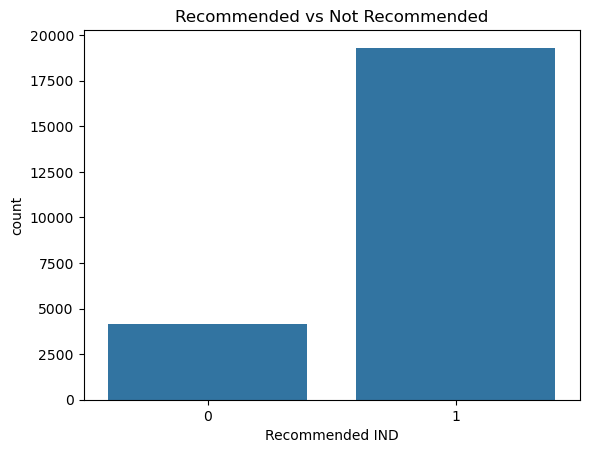

In [16]:
sns.countplot(x='Recommended IND', data=df)
plt.title("Recommended vs Not Recommended")
plt.show()

The distribution shows that the majority of observations are recommendations. This means the target variable is imbalanced. That insight becomes important later during modeling because a model could appear to perform well simply by predicting the majority class too often. Recognizing this imbalance early helps frame the evaluation stage more carefully.

## Rating Distribution

Ratings provide the clearest numerical summary of customer opinion, so I next examined how they are distributed across the dataset. This helps establish whether the review environment is balanced or already skewed toward positivity.

In [17]:
df['Rating'].value_counts().sort_index()

Rating
1      842
2     1565
3     2871
4     5077
5    13131
Name: count, dtype: int64

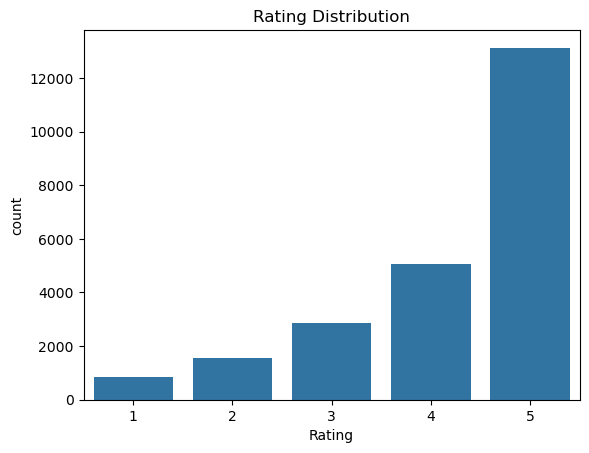

In [18]:
sns.countplot(x='Rating', data=df)
plt.title("Rating Distribution")
plt.show()

The rating distribution is heavily concentrated in the higher values, especially 4 and 5 stars. This suggests that the review environment is not neutral. Positive ratings dominate, which means dissatisfaction is less common but may be especially informative. This skew also helps explain why modeling recommendation behavior is more challenging than it first appears.

## Review Length

I was interested in whether review length might reflect stronger engagement, explanation, or dissatisfaction. Review length is not a direct opinion signal, but it can still tell us something about how much effort a customer puts into describing their experience.

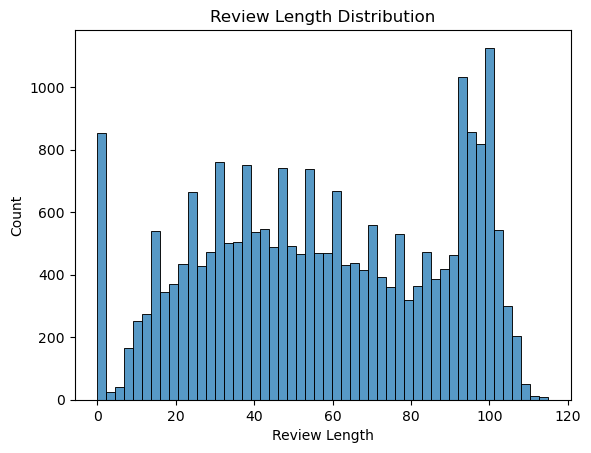

In [19]:
sns.histplot(df['Review_Length'], bins=50)
plt.title("Review Length Distribution")
plt.xlabel("Review Length")
plt.show()

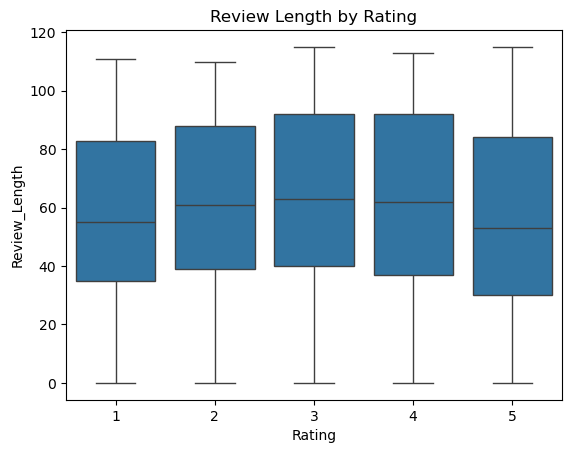

In [20]:
sns.boxplot(x='Rating', y='Review_Length', data=df)
plt.title("Review Length by Rating")
plt.show()

Review length varies substantially across the dataset. This was interesting to me because it suggests that customer engagement is not uniform. Some reviews are brief and direct, while others are much longer and more detailed. Even when review length is not the strongest predictor later in the model, it still contributes to understanding the behavioral texture of the data.

## Sentiment and Rating

This section explores how the emotional tone of the written review relates to the numerical rating. VADER's compound score (Hutto & Gilbert, 2014) is plotted against the star rating to reveal whether the two signals align or diverge. I expected sentiment and rating to be positively related, but I also wanted to see whether that relationship was clean or whether the written language revealed complications that the rating alone could not capture.

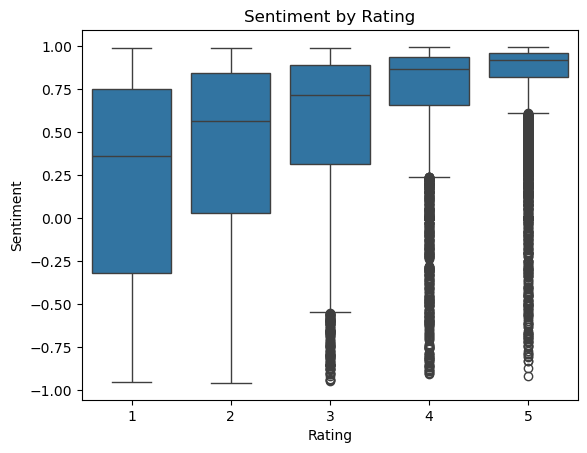

In [21]:
sns.boxplot(x='Rating', y='Sentiment', data=df)
plt.title("Sentiment by Rating")
plt.show()

In general, sentiment increases as rating increases, which is expected. However, the relationship is not perfect. This imperfection is one of the most important insights in the notebook. It suggests that the written review contains nuances that are not always captured by the star rating. That observation is part of what motivated the modeling phase.

## Correlation Analysis

To examine the relationships among the main numeric variables, I computed a correlation matrix. Correlation does not imply causation, but it provides a useful first look at whether certain signals tend to move together.

In [22]:
corr = df[['Rating', 'Sentiment', 'Review_Length', 'Positive Feedback Count']].corr()
corr

,Rating,Sentiment,Review_Length,Positive Feedback Count
Rating,1.000000,0.409622,-0.074392,-0.064961
Sentiment,0.409622,1.000000,0.224870,0.007829
Review_Length,-0.074392,0.224870,1.000000,0.205583
Positive Feedback Count,-0.064961,0.007829,0.205583,1.000000


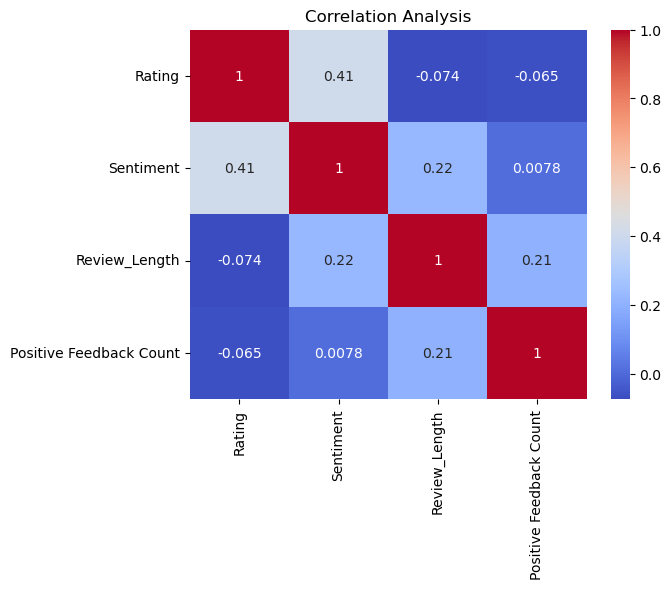

In [23]:
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Analysis")
plt.show()

The correlation between rating and sentiment is positive but not perfect. That matters because it suggests that sentiment is not simply a duplicate of rating. Review length and positive feedback count show weaker associations, which supports the idea that customer behavior is multidimensional and cannot be summarized by one variable alone.

## Looking at Inconsistencies

One of the most revealing parts of the analysis is looking at cases where rating and sentiment do not fully agree. These cases matter because they remind me that human feedback is structured enough to analyze but still messy enough to resist simple assumptions.

In [24]:
df[(df['Rating'] == 5) & (df['Sentiment'] < 0)][['Rating', 'Sentiment', 'Review Text']].head(10)

,Rating,Sentiment,Review Text
9,5,-0.3724,"I'm 5""5' and 125 lbs. i ordered the s petite t..."
180,5,-0.5284,"Loved the green color, the cut is super flatte..."
253,5,-0.0959,I have this dress on today in white and i am c...
354,5,-0.1239,"I saw this in-store, tried it on, and was sold..."
621,5,-0.2003,"When i tried on this bathing suit, i decided t..."
772,5,-0.4331,There's are just what i was looking for! these...
1375,5,-0.0044,"I bought the ""here comes the sun"" version of t..."
1443,5,-0.8035,Thrilled that this not only fits great on me b...
1500,5,-0.4005,Gorgeous colors on lovely silk skirt. longer o...
1566,5,-0.9137,I tried these on at the store and thought the ...


In [25]:
df[(df['Rating'] == 1) & (df['Sentiment'] > 0)][['Rating', 'Sentiment', 'Review Text']].head(10)

,Rating,Sentiment,Review Text
85,1,0.8454,"I was really hoping to like this, but it did n..."
97,1,0.8903,I was very excited to order this top in red xs...
161,1,0.8885,The title says it all....this fabric of this t...
209,1,0.7579,Love the fabric of this shirt even though it w...
241,1,0.8492,I loved this dress from the moment i tried it ...
334,1,0.8542,This top was way too short (i'm only 5'1) and ...
356,1,0.9345,The fabric was nothing special (i usually like...
389,1,0.8515,"I don't normally review my purchases, but i wa..."
565,1,0.9439,"This top runs super small in the upper arms, s..."
603,1,0.5103,"These run very small!! they are also short, al..."


These examples are important because they show why the project cannot stop at surface-level assumptions. A customer can give a high rating while still expressing frustration in the text, or use positive language while ending in a more negative overall judgment. Those inconsistencies are part of what made me want to test whether prediction could capture broader patterns more effectively than a single variable alone.

# Modeling & Prediction

## Why I moved into modeling

After EDA, I felt like I had reached a turning point. I was no longer just asking:
- what patterns exist?

I was now asking:
- can these patterns actually help predict behavior?

The target variable is Recommended IND, which makes this a binary classification problem. 1 means the customer recommended the product, 0 means they did not. But I want to be honest about something that took me a moment to think through: **if the dataset already contains this column, why would we need to predict it at all?**

The answer is about context, not the data itself. In this dataset, we have everything, the rating, the review text, and the recommendation label, because it was collected all at once. But in a real business setting, a company would often have new reviews coming in where a customer writes text and gives a star rating, but the downstream behavioral signal, whether they would actually recommend the product to someone, is not yet known or was never recorded. The model learns from the historical pattern of how rating, sentiment, review length, and engagement relate to recommendation behavior, so it can generalize to those future cases.
There is also a second reason that matters more to me analytically. Even within this dataset, building a classifier and examining which features drive the prediction tells us something the column alone cannot. It reveals what it is about a review that predicts recommendation, which combination of signals matters most. That is different from simply reading the label. The model is not just copying the answer; it is explaining the pattern behind it.
I also found this transition exciting because it changed the purpose of the notebook. EDA helped me understand the structure of the data, but modeling gave me a way to test whether that structure could actually be used. That shift from description to prediction is what made the project feel more complete.

## Why I Chose a Decision Tree

I chose a Decision Tree because I wanted a model that I could both interpret and explain clearly (Pedregosa et al., 2011). Since this project is not only about producing a classification result but also about understanding how the prediction is made, I did not want to begin with a black-box model. A decision tree mirrors human reasoning by splitting the data through a sequence of questions, such as whether the rating is high or whether the sentiment is positive.

What I liked most about this model is that it does not only return predictions. It also reveals the structure behind those predictions. That mattered to me because one of the goals of this notebook is to learn what the data can teach, not just to maximize performance.

## Features and Assumptions

For modeling, I selected features that represent different sides of customer behavior: `Rating`, `Sentiment`, `Review_Length`, and `Positive Feedback Count`. Together, these variables combine direct evaluation, emotional tone from VADER (Hutto & Gilbert, 2014), level of explanation, and social response.

At the same time, I recognize that the model rests on assumptions. It assumes that reviews are honest enough to reflect meaningful customer experience, that sentiment analysis captures enough emotional tone to be useful, and that these selected variables carry predictive information about recommendation behavior. The model also assumes that patterns observed in past reviews can generalize to new ones. These assumptions make the modeling possible, but they also define its limitations.

In [26]:
features = ['Rating', 'Sentiment', 'Review_Length', 'Positive Feedback Count']
X = df[features]
y = df['Recommended IND']

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Training the Model

Because the recommendation classes are imbalanced, I used `class_weight='balanced'` so that the model would not ignore the minority class (Pedregosa et al., 2011).

This decision mattered to me because I did not want the model to look successful while only learning the majority outcome.

In [28]:
tree = DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=4)
tree.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=4, random_state=42)

In [29]:
y_pred = tree.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.94      0.84       835
           1       0.99      0.93      0.96      3863

    accuracy                           0.94      4698
   macro avg       0.87      0.94      0.90      4698
weighted avg       0.95      0.94      0.94      4698



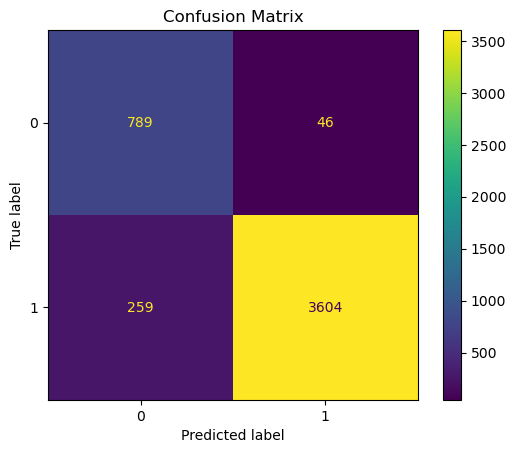

In [30]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

## Interpreting the Confusion Matrix

The confusion matrix helps move the evaluation from abstract metrics into practical meaning. In this application, a true positive means the model correctly identifies a review that recommends the product, while a true negative means it correctly identifies a review that does not recommend it. A false positive means the model predicts recommendation even though the customer would not recommend the product, and a false negative means the model fails to detect a genuinely positive recommendation.

In the context of product review analysis, these errors matter differently. A false positive may be especially problematic because it could lead a company to interpret dissatisfaction as satisfaction, causing it to overlook product issues. On the other hand, a false negative may underestimate customer approval. Looking at the confusion matrix therefore helps me think beyond overall accuracy and ask whether the model is making the kinds of mistakes that would matter in practice.

## Improving the Model

After building the first version of the model, I wanted to see whether performance could improve by tuning the tree. This step is important because decision trees can overfit if they grow too deep (Pedregosa et al., 2011). So instead of assuming the first version is best, I used grid search to test different combinations of parameters.

In [31]:
param_grid = {
    'max_depth': [3, 4, 5, 6, 8],
    'min_samples_split': [2, 10, 20, 50],
    'min_samples_leaf': [1, 5, 10, 20]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)
grid.best_params_, grid.best_score_

({'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2},
 np.float64(0.9601706626668596))

In [32]:
best_tree = grid.best_estimator_
y_pred_best = best_tree.predict(X_test)

print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.76      0.95      0.84       835
           1       0.99      0.93      0.96      3863

    accuracy                           0.94      4698
   macro avg       0.87      0.94      0.90      4698
weighted avg       0.95      0.94      0.94      4698



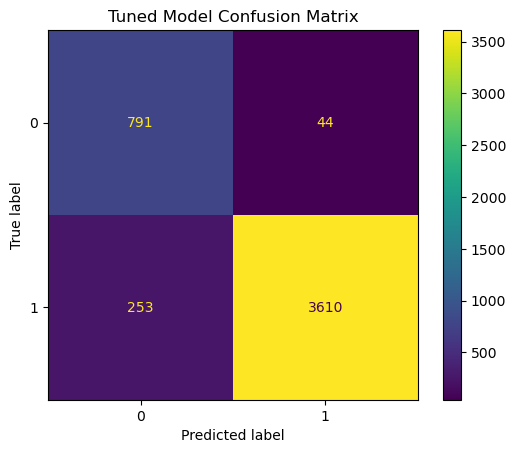

In [33]:
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Tuned Model Confusion Matrix")
plt.show()

## Visualizing the Decision Tree

One reason I found this model enjoyable is that its logic can be visualized (Pedregosa et al., 2011). That makes the prediction process feel less abstract. Instead of simply accepting the output, I can see which variables the model uses and how those decision paths are structured.

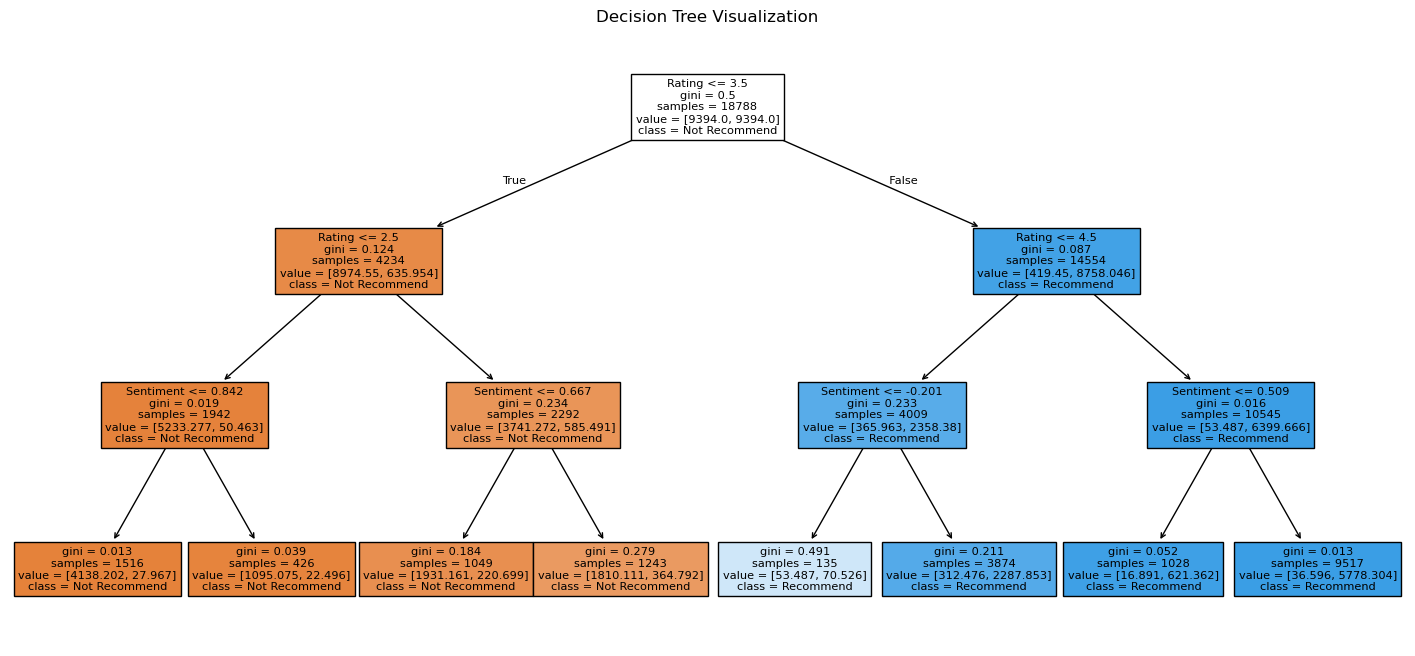

In [34]:
plt.figure(figsize=(18, 8))
plot_tree(
    best_tree,
    filled=True,
    feature_names=features,
    class_names=['Not Recommend', 'Recommend']
)
plt.title("Decision Tree Visualization")
plt.show()

## Feature Importance

Feature importance provides insight into which variables the decision tree relied on most when making predictions (Pedregosa et al., 2011). This matters because prediction accuracy alone does not tell the full story. I also want to know what the model is learning from.

In [35]:
importance = pd.Series(best_tree.feature_importances_, index=features).sort_values(ascending=False)
importance

Rating                     0.995658
Sentiment                  0.004342
Review_Length              0.000000
Positive Feedback Count    0.000000
dtype: float64

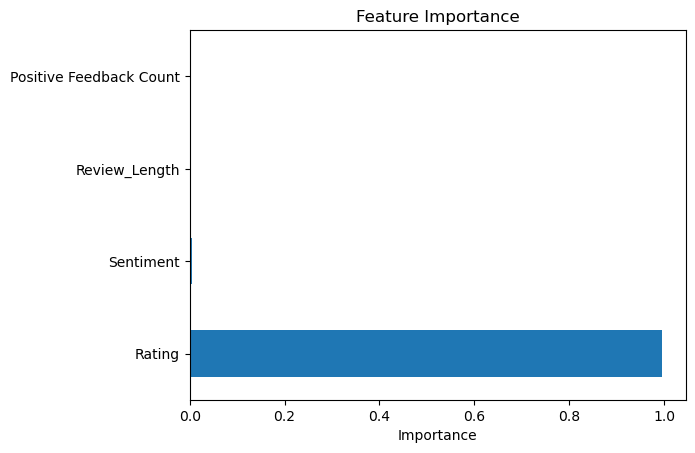

In [36]:
importance.plot(kind='barh')
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.show()

## Is Sentiment Still Necessary?

Because rating appears as the strongest feature in the decision tree, it is reasonable to ask whether sentiment analysis is truly necessary. In one sense, rating already captures a large share of the predictive signal because it is a direct numerical summary of customer opinion. That means sentiment may add less predictive power when rating is already included in the model.

However, I do not think this makes sentiment unnecessary. Sentiment still adds interpretive value because it captures the emotional tone behind the review and helps identify cases where the written language does not fully align with the numeric rating (Hutto & Gilbert, 2014). That was one of the most interesting findings in the EDA stage. In addition, sentiment would become especially useful in situations where a company has review text but not a structured rating, such as scraped comments, support messages, or open-ended feedback forms. So even if rating dominates prediction in this model, sentiment still contributes to a richer understanding of customer behavior.

## What the Model Taught Me

The most interesting part of this stage was realizing that the model confirmed some of my expectations but also made me think more critically about what prediction actually means. Rating is clearly powerful, which makes sense. But what I found more meaningful is that the project showed how behavior is structured without ever becoming perfectly clean.

What I enjoyed most was the feeling of moving from confusion to pattern. At first, customer reviews felt messy. Then EDA gave me relationships and inconsistencies. Then modeling gave me a way to test whether those patterns were strong enough to support prediction. That progression is what made the project fun for me. It felt like building understanding step by step instead of forcing the data to say something too quickly.

## Why Human Judgment Still Matters

One question that stayed with me throughout the project is whether tools that generate code or automate modeling reduce the importance of human analysts. My answer is no. They change the work, but they do not remove the need for it.

My role in this project was not simply to run code. It was to decide what question matters, choose which variables to engineer, recognize the class imbalance problem, interpret what the confusion matrix means, and connect the results to a real-world use case. The model can identify statistical structure, but it cannot fully understand context, sarcasm, expectations, or why a mismatch between rating and language matters. That interpretive layer is what still makes the human role essential.

# Rating vs. Sentiment Comparison Tool

## From prediction to interactive insight

One extension that I found exciting is turning this project into a practical business tool: a **Rating vs. Sentiment Comparison Dashboard**. The original idea was a simple paste-and-predict interface built with Django. But the more impactful direction is a tool that lets companies *compare* what customers say with what they rate, making the mismatch visible and actionable.

The key insight from this project is that ratings and sentiment do not always agree (Hutto & Gilbert, 2014). A company that can see that gap at scale has a real competitive advantage: it can detect products that look acceptable on paper but are generating genuinely frustrated language, or products that customers love in their writing but rate conservatively out of habit.

The dashboard would allow teams to:
- Upload or paste a batch of reviews with their associated star ratings
- Automatically compute VADER sentiment scores for each review (Hutto & Gilbert, 2014)
- Visualize each review on a scatter plot: x-axis = star rating, y-axis = sentiment score
- Flag mismatches, reviews where sentiment and rating diverge significantly, so product teams can investigate
- Export the full analysis as a CSV for further reporting

This transforms the notebook from a one-time analysis into a repeatable tool for any review dataset.

## Why comparison is more valuable than prediction

The original Django app idea focused on predicting whether a single pasted review would result in a recommendation. That is useful, but it has a limitation: the company already has the star rating. Predicting something they can already read does not add much value.

The comparison approach is different. It answers a question the rating alone cannot: *does this customer's language match what they scored?* A five-star review that reads as frustrated is a signal the rating hides. A two-star review written in positive language may reflect size or shipping disappointment rather than product failure. These distinctions matter enormously for inventory, marketing, and product development decisions.

Aggregate views add even more value. When companies look at 500 reviews together, seeing average sentiment per star band, spotting product categories where mismatches cluster, they gain insights no individual prediction can provide.

## Technical approach

The tool uses the same VADER scoring pipeline from this notebook (Hutto & Gilbert, 2014; Bird, Klein, & Loper, 2009) and is built as a front-end JavaScript application so it can run in any browser without a server. Reviews and ratings are entered or uploaded, scored locally, and displayed in three views:
1. **Scatter plot** — each dot is one review, positioned by its star rating (x) and sentiment score (y). A diagonal reference line shows perfect alignment. Dots far from the line are mismatches.
2. **Review table** — a detailed list with sentiment bars and Agree / Partial / Mismatch badges.
3. **Distribution chart** — average sentiment per star rating band, showing where emotional tone and numeric scores diverge most.

A one-click CSV export includes rating, sentiment score, match status, and review text, making the output easy to share with non-technical stakeholders.

## Example: batch scoring logic (Python)

The following function shows how a backend could process a list of reviews and return structured output for the dashboard.

In [37]:
def score_reviews(review_texts, ratings, sia):
    """
    Compare star ratings to VADER sentiment for a batch of reviews.
    Returns a DataFrame with sentiment scores and mismatch flags.

    Parameters
    ----------
    review_texts : list of str
    ratings      : list of int (1–5)
    sia          : SentimentIntensityAnalyzer instance (Hutto & Gilbert, 2014)
    """
    results = []
    for text, rating in zip(review_texts, ratings):
        sentiment = sia.polarity_scores(text)['compound']
        expected  = (rating - 3) / 2          # map 1-5 → -1 to +1
        gap       = abs(sentiment - expected)
        if gap < 0.35:
            match = 'Agree'
        elif gap < 0.65:
            match = 'Partial'
        else:
            match = 'Mismatch'
        results.append({'Review': text, 'Rating': rating,
                        'Sentiment': round(sentiment, 2), 'Match': match})
    return pd.DataFrame(results)


# Example usage
sample_texts   = ["Absolutely love this dress!", "Terrible quality, very disappointed."]
sample_ratings = [5, 2]
score_reviews(sample_texts, sample_ratings, sia)

,Review,Rating,Sentiment,Match
0,Absolutely love this dress!,5,0.70,Agree
1,"Terrible quality, very disappointed.",2,-0.76,Agree


## Automatic CSV export

The cell below saves the full review-level analysis — including sentiment scores and match flags — to a CSV file for use in reports or the dashboard.

In [38]:
# Run this after feature engineering to export the enriched dataset
output_cols = ['Review Text', 'Rating', 'Sentiment', 'Review_Length',
               'Positive Feedback Count', 'Recommended IND']

export_df = df[output_cols].copy()

# Add match classification
def classify_match(row):
    expected = (row['Rating'] - 3) / 2
    gap = abs(row['Sentiment'] - expected)
    if gap < 0.35:  return 'Agree'
    elif gap < 0.65: return 'Partial'
    else:            return 'Mismatch'

export_df['Match'] = export_df.apply(classify_match, axis=1)

export_path = 'review_sentiment_analysis.csv'
export_df.to_csv(export_path, index=False)
print(f"Saved {len(export_df):,} rows to {export_path}")

Saved 23,486 rows to review_sentiment_analysis.csv


# Conclusion

This project began with a simple curiosity about customer reviews, but it became much more than a basic classification exercise. Through exploratory data analysis, I learned that customer behavior is not always consistent. Ratings, language, and recommendation do not always move together in simple ways. Through modeling using scikit-learn (Pedregosa et al., 2011), I learned that prediction is possible, but interpretation still matters. The decision tree helped structure the patterns, but it did not erase the complexity behind them.

What I liked most about this project was that it let me move between numbers and meaning. I was not only analyzing columns. I was trying to understand how people express satisfaction, disappointment, and mixed experiences, using VADER sentiment scoring (Hutto & Gilbert, 2014) to make that language legible to a model. The data itself came from a real e-commerce context that made the stakes feel concrete (Kaggle, n.d.).

If I continue the project, I would like to expand the feature set, compare additional models, and build the rating-versus-sentiment dashboard into a full production tool. For me, this notebook is not only about machine learning. It is about using data to get closer to how people actually respond and how those responses can inform better decisions.

# References

Bird, S., Klein, E., & Loper, E. (2009). *Natural language processing with Python*. O'Reilly Media.

Hutto, C. J., & Gilbert, E. (2014). VADER: A parsimonious rule-based model for sentiment analysis of social media text. *Proceedings of the International AAAI Conference on Web and Social Media, 8*(1), 216–225.

Kaggle. (n.d.). *Women's e-commerce clothing reviews dataset*. Retrieved from https://www.kaggle.com/datasets/nicapotato/womens-ecommerce-clothing-reviews

McKinney, W. (2010). Data structures for statistical computing in Python. *Proceedings of the 9th Python in Science Conference*, 445, 51–56.

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, E. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.